In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!unzip /content/drive/MyDrive/vision/classification_dataset.zip -d /content/drive/MyDrive/vision

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/vision/classification_dataset/train/5/00005_00016_00013.png  
  inflating: /content/drive/MyDrive/vision/classification_dataset/train/5/00005_00016_00014.png  
  inflating: /content/drive/MyDrive/vision/classification_dataset/train/5/00005_00016_00015.png  
  inflating: /content/drive/MyDrive/vision/classification_dataset/train/5/00005_00016_00016.png  
  inflating: /content/drive/MyDrive/vision/classification_dataset/train/5/00005_00016_00017.png  
  inflating: /content/drive/MyDrive/vision/classification_dataset/train/5/00005_00016_00018.png  
  inflating: /content/drive/MyDrive/vision/classification_dataset/train/5/00005_00016_00019.png  
  inflating: /content/drive/MyDrive/vision/classification_dataset/train/5/00005_00016_00020.png  
  inflating: /content/drive/MyDrive/vision/classification_dataset/train/5/00005_00016_00021.png  
  inflating: /content/drive/MyDrive/vision/classification_dataset/t

In [2]:
!pip install tensorflow numpy matplotlib scikit-learn


Found 10848 images belonging to 9 classes.
Found 2712 images belonging to 9 classes.
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


339/339 ━━━━━━━━━━━━━━━━━━━━ 54s 139ms/step - accuracy: 0.2764 - loss: 1.8706 - val_accuracy: 0.6313 - val_loss: 1.0118
Epoch 2/10


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


339/339 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5417 - val_loss: 1.0805
Epoch 3/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 67s 139ms/step - accuracy: 0.8211 - loss: 0.5425 - val_accuracy: 0.8501 - val_loss: 0.4488
Epoch 4/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9167 - val_loss: 0.4999
Epoch 5/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - accuracy: 0.9387 - loss: 0.2072 - val_accuracy: 0.9222 - val_loss: 0.2092
Epoch 6/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.8750 - val_loss: 0.3560
Epoch 7/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.9623 - loss: 0.1198 - val_accuracy: 0.9033 - val_loss: 0.3107
Epoch 8/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.9167 - val_loss: 0.1690
Epoch 9/10
339/339 ━━━━━━━━━━━━━━━━━━━━ 83s 141ms/step - accuracy: 0.970

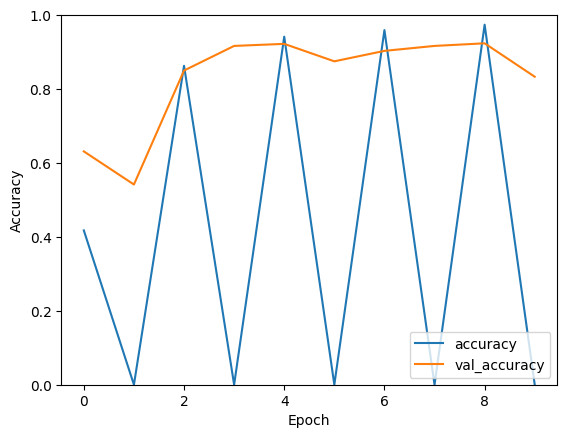

In [5]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the paths for your dataset
train_dir = '/content/drive/MyDrive/vision/classification_dataset/train'
#test_dir = '/path/to/your/test/dataset'

# Define custom class names corresponding to each folder (0 to 8)
class_names = ['speedLimit_20', 'speedLimit_30', 'speedLimit_50',
               'speedLimit_60', 'speedLimit_70', 'speedLimit_80',
               'speedLimit_100', 'speedLimit_120', 'Stop']

# Create a dictionary to map folder numbers to class names
class_map = {str(i): class_names[i] for i in range(len(class_names))}

# Preprocess and split data
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load and preprocess the data for training and validation
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),  # Resize images to 64x64 (you can adjust the size)
    batch_size=32,
    class_mode='categorical',  # Use categorical labels (one-hot encoded)
    subset='training',  # Only use training data here
    classes=list(class_map.values())  # Map the folders to class names
)

valid_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',  # Use categorical labels (one-hot encoded)
    subset='validation',  # Use validation data here
    classes=list(class_map.values())  # Map the folders to class names
)



# Build the model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')  # Number of classes defined in custom class_names
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,  # You can change the number of epochs
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // valid_generator.batch_size
)

# Plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

# Save the model for future use
model.save('/path/to/save/traffic_sign_classifier_model.h5')




In [6]:
# Save the model for future use
model.save('/content/drive/MyDrive/vision/classification_dataset/traffic_sign_classifier_model.h5')

In [3]:
!unzip /content/test2.zip -d /content/drive/MyDrive

Archive:  /content/test2.zip
   creating: /content/drive/MyDrive/test2/
  inflating: /content/drive/MyDrive/test2/00001.png  
  inflating: /content/drive/MyDrive/test2/00011.png  
  inflating: /content/drive/MyDrive/test2/00024.png  
  inflating: /content/drive/MyDrive/test2/00034.png  
  inflating: /content/drive/MyDrive/test2/00062.png  
  inflating: /content/drive/MyDrive/test2/00068.png  
  inflating: /content/drive/MyDrive/test2/00086.png  
  inflating: /content/drive/MyDrive/test2/00092.png  
  inflating: /content/drive/MyDrive/test2/00093.png  
  inflating: /content/drive/MyDrive/test2/00105.png  
  inflating: /content/drive/MyDrive/test2/00111.png  
  inflating: /content/drive/MyDrive/test2/00124.png  
  inflating: /content/drive/MyDrive/test2/00128.png  
  inflating: /content/drive/MyDrive/test2/00217.png  
  inflating: /content/drive/MyDrive/test2/00224.png  
  inflating: /content/drive/MyDrive/test2/00366.png  
  inflating: /content/drive/MyDrive/test2/01198.png  
  inflatin

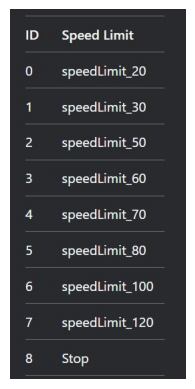

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

# Path to the image in Google Drive
image_path = '/content/drive/MyDrive/vision/class table.JPG'

# Open the image
img = Image.open(image_path)

# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


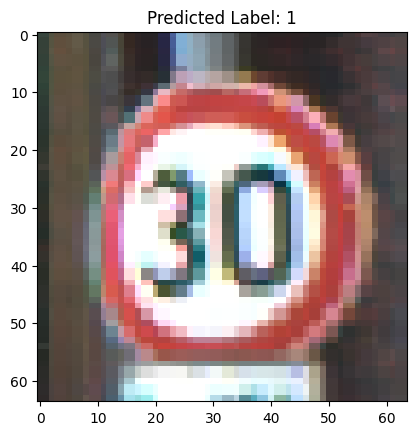

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


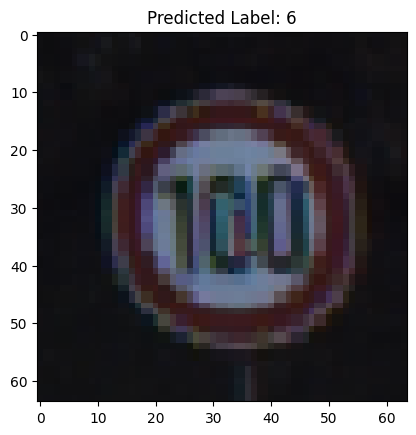

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


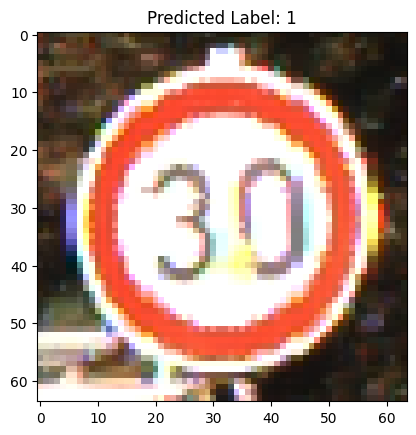

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


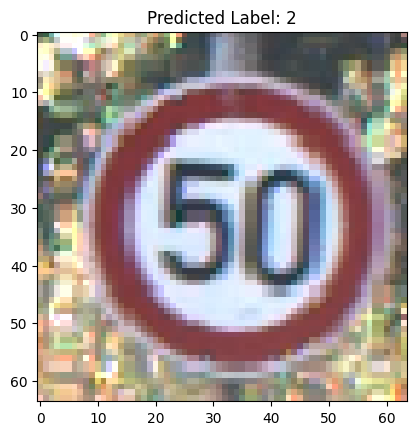

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


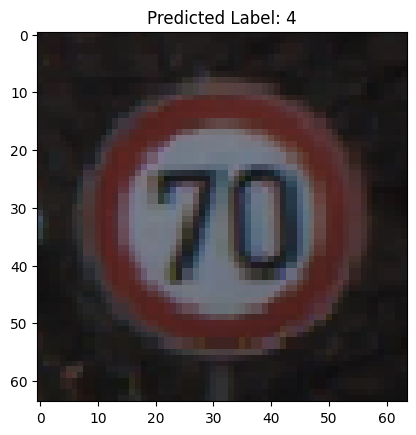

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


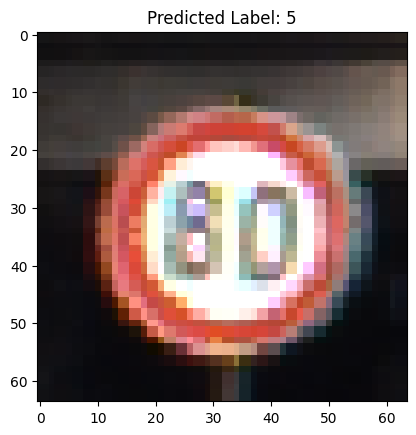

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


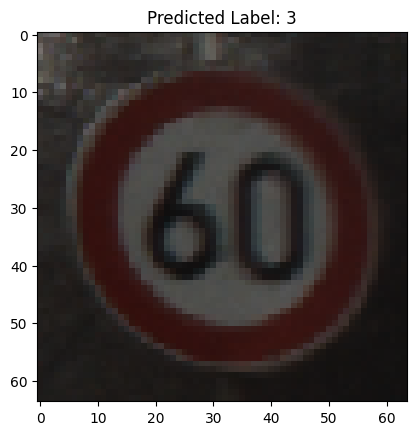

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


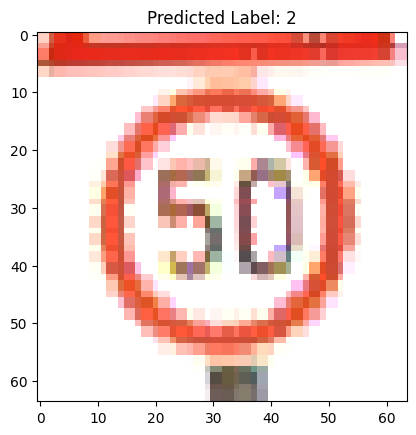

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


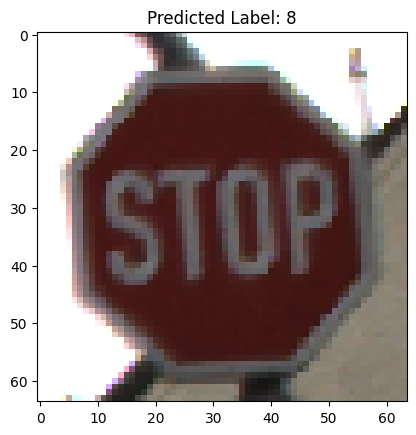

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


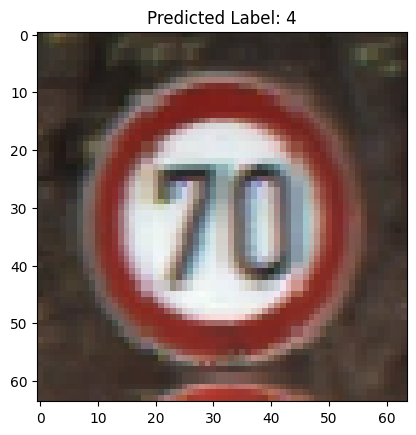

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


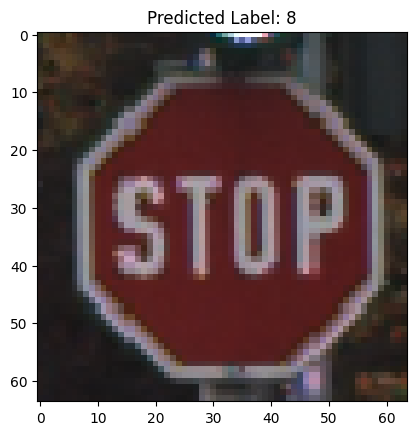

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


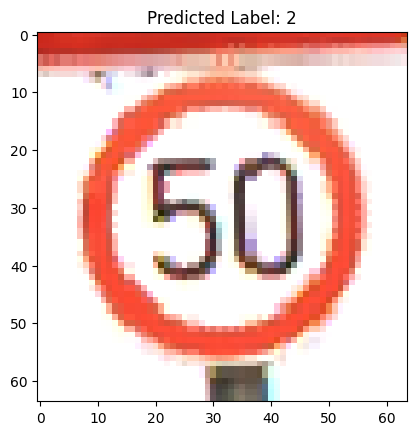

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


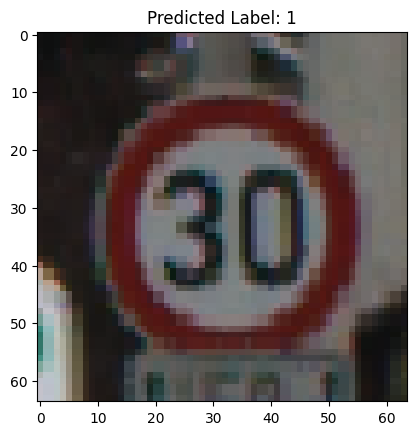

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


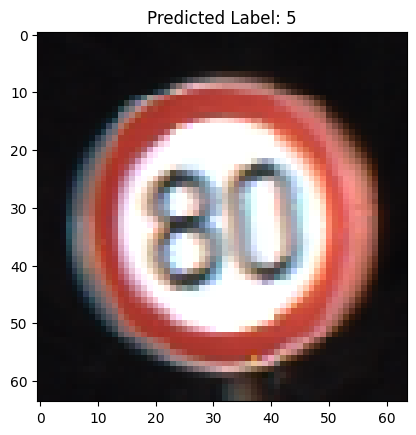

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


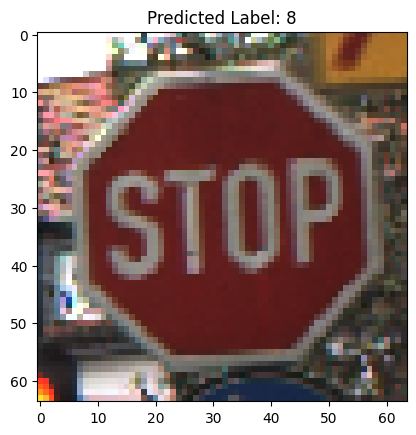

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


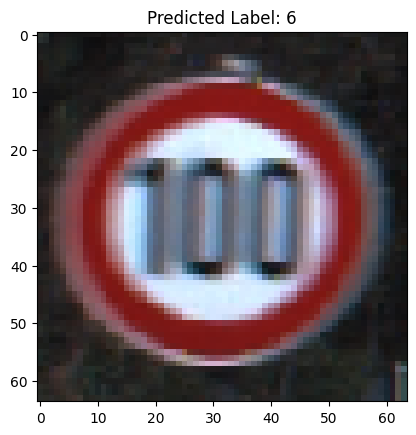

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


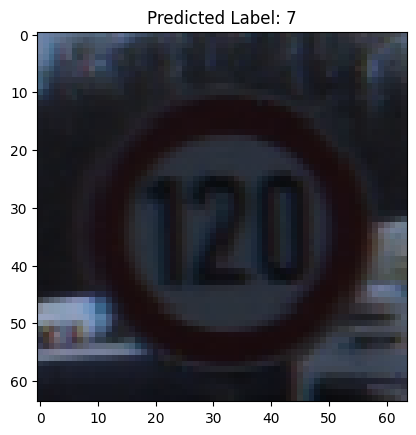

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


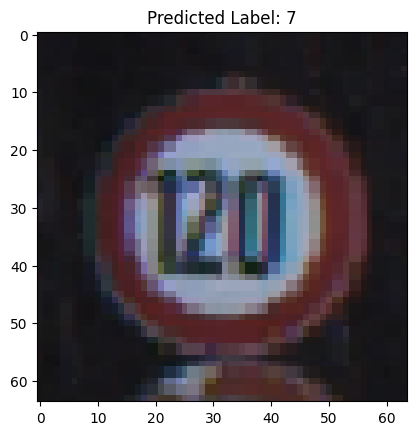

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array

# Load the model
model = load_model('/content/drive/MyDrive/vision/classification_dataset/traffic_sign_classifier_model.h5')

# Define the test dataset folder path
test_data_path = '/content/drive/MyDrive/test2'

# Get the test images (you can modify this to suit your data structure)
test_images = os.listdir(test_data_path)

# Loop through the images in the test dataset and predict
for img_name in test_images:
    img_path = os.path.join(test_data_path, img_name)

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(64, 64))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict the label
    prediction = model.predict(img_array)
    predicted_label = np.argmax(prediction, axis=1)[0]

    # Display the image and predicted label
    plt.imshow(img)
    plt.title(f'Predicted Label: {predicted_label}')
    plt.show()
